**Test the ability of the skull stripping and bias field correction model**

1. Skull stripping model is able to include tumor region as part of the brain during extraction if using 't1' and 't2'
2. Bias field correction model took a lot of time in processing hence will not be adpoed in this project but still a good preprocessing approach to consider in the future

In [1]:
import ants
import antspynet

In [2]:
t1 = ants.image_read(r"C:\Users\hp\Downloads\3D-MR-MS_patient01-05\patient01\patient01_T1W.nii.gz")
t2 = ants.image_read(r"C:\Users\hp\Downloads\3D-MR-MS_patient01-05\patient01\patient01_T2W.nii.gz")

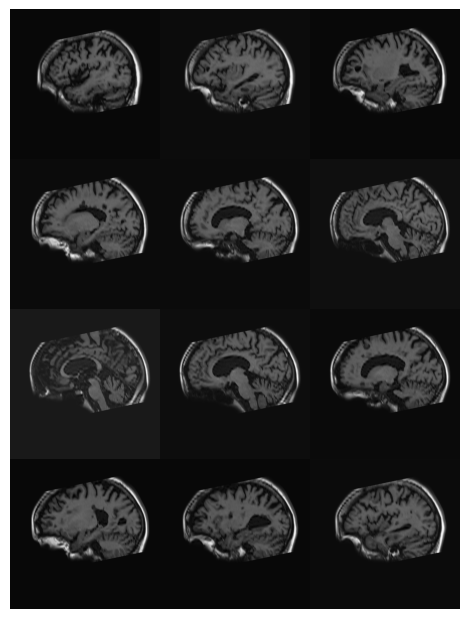

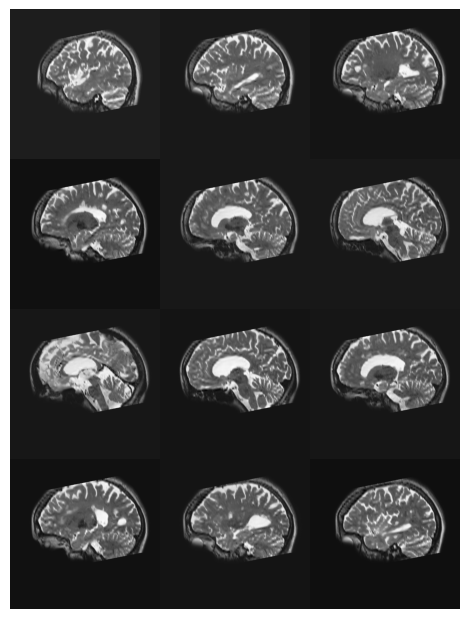

In [3]:
ants.plot(t1)
ants.plot(t2)

Brain extraction:  retrieving model weights.
Brain extraction:  retrieving template.
Brain extraction:  normalizing image to the template.
Brain extraction:  prediction and decoding.
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Brain extraction:  renormalize probability mask to native space.
Brain extraction:  retrieving model weights.
Brain extraction:  retrieving template.
Brain extraction:  normalizing image to the template.
Brain extraction:  prediction and decoding.
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Brain extraction:  renormalize probability mask to native space.


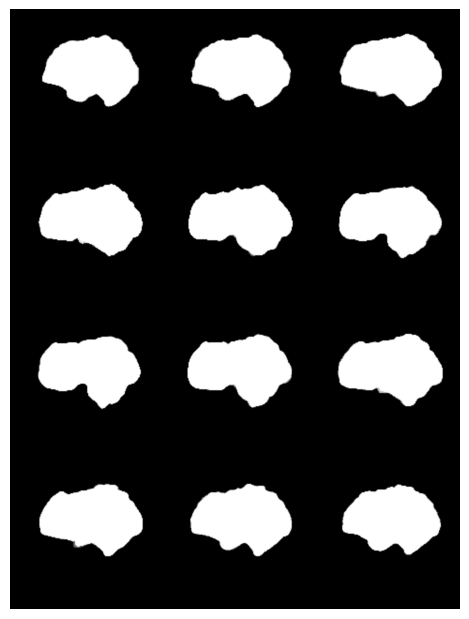

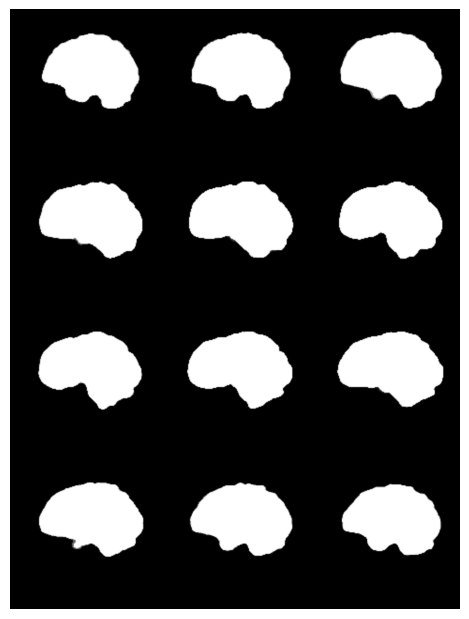

In [4]:
brain_mask_t1 = antspynet.brain_extraction(t1, modality="t1", verbose=True)
brain_mask_t2 = antspynet.brain_extraction(t2, modality="t2", verbose=True)

ants.plot(brain_mask_t1)
ants.plot(brain_mask_t2)

In [5]:
import numpy as np

# Get unique pixel values
unique_values_t1 = np.unique(brain_mask_t1.numpy())
unique_values_t2 = np.unique(brain_mask_t2.numpy())

# Print distinct values
print("Unique values in brain_mask_t1:", unique_values_t1)
print("Unique values in brain_mask_t2:", unique_values_t2)

Unique values in brain_mask_t1: [0.0000000e+00 2.8025969e-45 5.6051939e-45 ... 9.9999988e-01 9.9999994e-01
 1.0000000e+00]
Unique values in brain_mask_t2: [0.0000000e+00 1.5414283e-44 1.6815582e-44 ... 9.9999988e-01 9.9999994e-01
 1.0000000e+00]


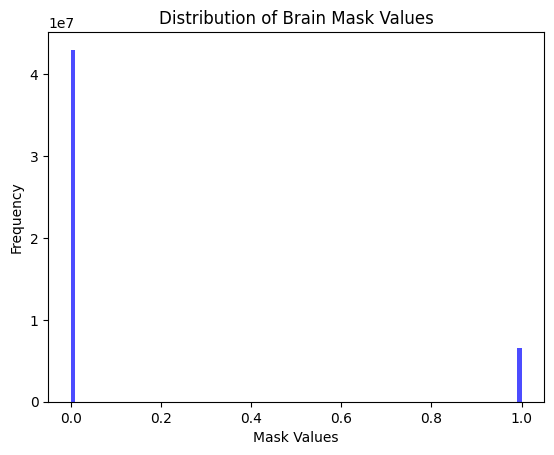

In [6]:
import matplotlib.pyplot as plt

# Assuming brain_mask is a NumPy array
plt.hist(brain_mask_t1.numpy().flatten(), bins=100, color='blue', alpha=0.7)
plt.xlabel("Mask Values")
plt.ylabel("Frequency")
plt.title("Distribution of Brain Mask Values")
plt.show()

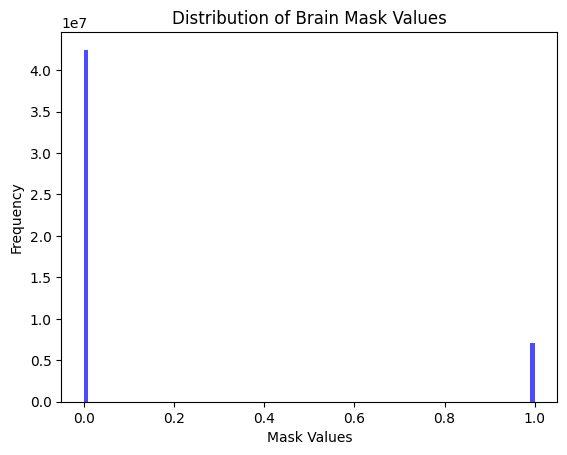

In [7]:
# Assuming brain_mask is a NumPy array
plt.hist(brain_mask_t2.numpy().flatten(), bins=100, color='blue', alpha=0.7)
plt.xlabel("Mask Values")
plt.ylabel("Frequency")
plt.title("Distribution of Brain Mask Values")
plt.show()

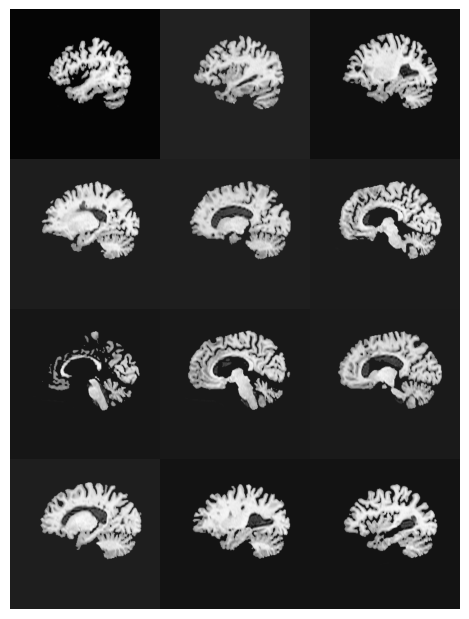

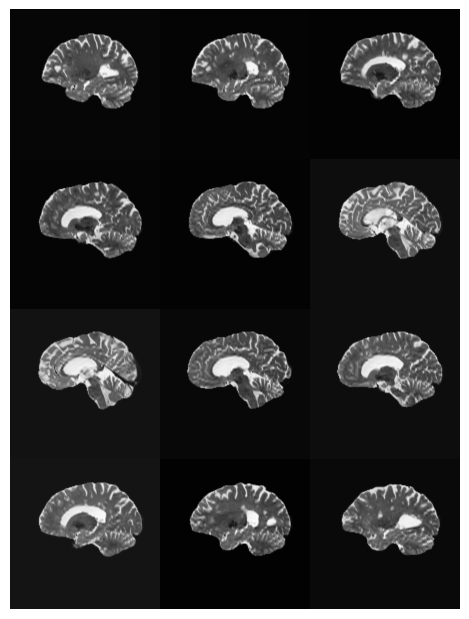

In [6]:
stripped_t1 = t1 * brain_mask_t1
stripped_t2 = t2 * brain_mask_t2

ants.plot(stripped_t1)
ants.plot(stripped_t2)

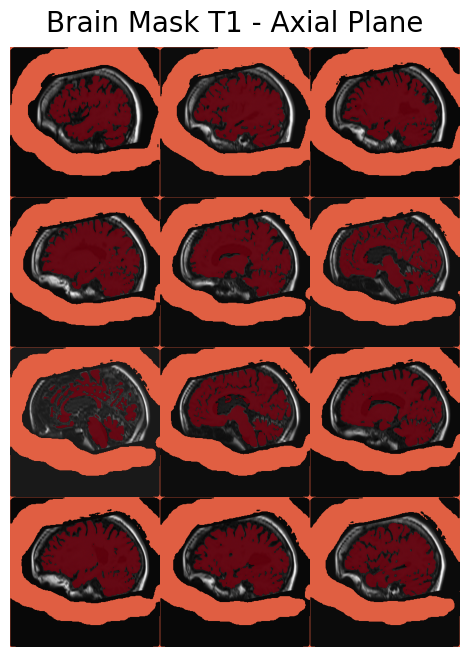

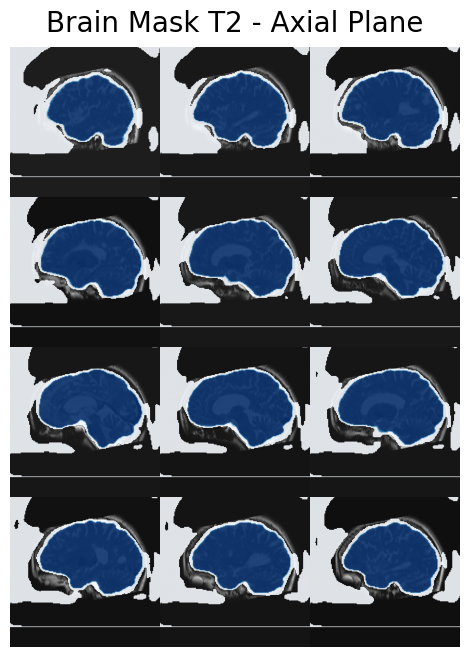

In [7]:
# Plot the brain mask for T1 with overlay
ants.plot(t1, overlay=brain_mask_t1, overlay_cmap='Reds', title='Brain Mask T1 - Axial Plane')

# Plot the brain mask for T2 with overlay
ants.plot(t2, overlay=brain_mask_t2, overlay_cmap='Blues', title='Brain Mask T2 - Axial Plane')

Brain extraction:  retrieving model weights.
5683832/5683832 ━━━━━━━━━━━━━━━━━━━━ 9s 2us/step
Brain extraction:  retrieving template.
Brain extraction:  normalizing image to the template.
Brain extraction:  prediction and decoding.
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Brain extraction:  renormalize probability mask to native space.


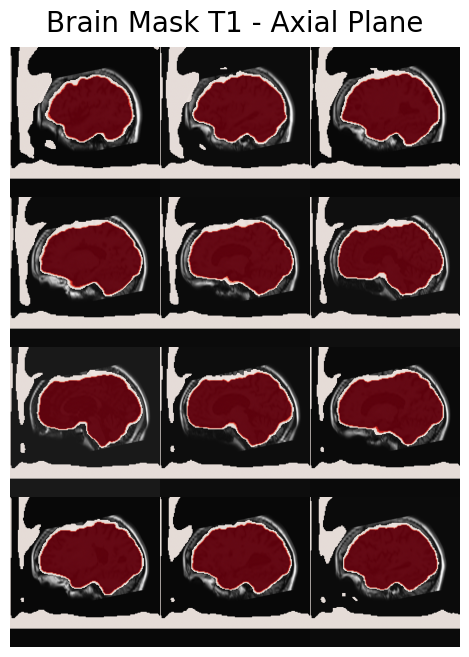

In [9]:
brain_mask_t1_pure = antspynet.brain_extraction(t1, modality="t1", verbose=True)
ants.plot(t1, overlay=brain_mask_t1_pure, overlay_cmap='Reds', title='Brain Mask T1 - Axial Plane')

In [10]:
import SimpleITK as sitk
import matplotlib.pyplot as plt

<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type swigvarlink has no __module__ attribute


In [ ]:
stripped_t1 = t1 * brain_mask_t1_pure
stripped_t2 = t2 * brain_mask_t2

sitk_t1 = sitk.GetImageFromArray(stripped_t1.numpy())
sitk_t2 = sitk.GetImageFromArray(stripped_t2.numpy())

corrected_t1 = sitk.N4BiasFieldCorrection(sitk_t1)
corrected_t2 = sitk.N4BiasFieldCorrection(sitk_t2)

In [ ]:
# Convert SimpleITK image to numpy array for visualization
array_b4_corrected_t1 = sitk.GetArrayFromImage(sitk_t1)
array_b4_corrected_t2 = sitk.GetArrayFromImage(sitk_t2)

array_corrected_t1 = sitk.GetArrayFromImage(corrected_t1)
array_corrected_t2 = sitk.GetArrayFromImage(corrected_t2)

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

# Plot before correction 
axes[0, 0].imshow(array_b4_corrected_t1[array_b4_corrected_t1.shape[0] // 2, :, :], cmap='gray')
axes[0, 0].set_title("Before Bias Field Correction: T1 Sagittal Plane")
axes[0, 0].axis('off')

axes[1, 0].imshow(array_b4_corrected_t2[array_b4_corrected_t2.shape[0] // 2, :, :], cmap='gray')
axes[1, 0].set_title("Before Bias Field Correction: T2 Sagittal Plane")
axes[1, 0].axis('off')

# Plot after correction 
axes[0, 1].imshow(array_corrected_t1[array_corrected_t1.shape[0] // 2, :, :], cmap='gray')
axes[0, 1].set_title("After Bias Field Correction: T1 Sagittal Plane")
axes[0, 1].axis('off')

axes[1, 1].imshow(array_corrected_t2[array_corrected_t2.shape[0] // 2, :, :], cmap='gray')
axes[1, 1].set_title("After Bias Field Correction: T2 Sagittal Plane")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()